In [1]:
import numpy as np
import pandas as pd

In [2]:
data='https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
!wget $data

--2026-08-24 14:28:49--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv.2’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.009s  

2026-08-24 14:28:50 (95.2 MB/s) - ‘car_fuel_efficiency.csv.2’ saved [874188/874188]



In [3]:
df = pd.read_csv(data)

In [4]:
df.columns=df.columns.str.replace(' ','_').str.lower()

In [5]:
columns = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']

In [6]:
df = df[columns]

In [7]:
df.isna().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [8]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

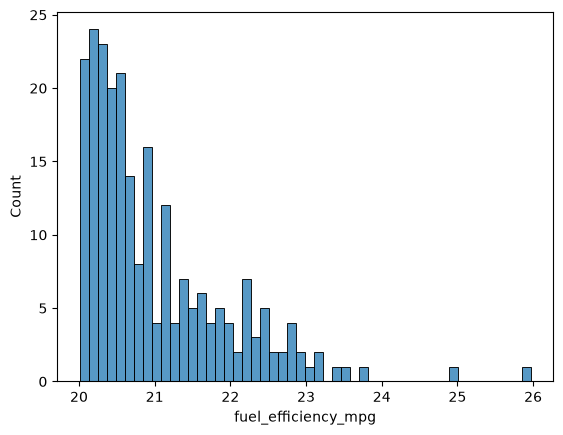

In [10]:
sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg>20], bins = 50)

In [11]:
mean_horsepower = df['horsepower'].mean()

In [12]:
n = len(df)
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

In [13]:
df_train=df.iloc[idx[:n_train]]
df_val=df.iloc[idx[n_train:n_train+n_val]]
df_test=df.iloc[idx[n_val+n_train:]]


In [14]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [15]:
y_train=np.log1p(df_train.fuel_efficiency_mpg.values)
y_val=np.log1p(df_val.fuel_efficiency_mpg.values)
y_test=np.log1p(df_test.fuel_efficiency_mpg.values)

In [16]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [17]:
def prepare_X(df,fill_value):
    df = df.copy()
    # features = base.copy()
    X = df.fillna(fill_value).values
    return X

In [18]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
     
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
     
    return w_full[0], w_full[1:]

In [19]:
X_train_0 = prepare_X(df_train, 0)
w0_0, w_0 = train_linear_regression(X_train_0, y_train)

In [20]:
X_val_0 = prepare_X(df_val, 0)
y_pred_0 = w0_0 + X_val_0.dot(w_0)
rmse_0 = np.sqrt(((y_val - y_pred_0) ** 2).mean())

In [21]:
X_train_m = prepare_X(df_train, mean_horsepower)
w0_m, w_m = train_linear_regression(X_train_m, y_train)

X_val_m = prepare_X(df_val, mean_horsepower)
y_pred_m = w0_m + X_val_m.dot(w_m)
rmse_m = np.sqrt(((y_val - y_pred_m) ** 2).mean())

In [22]:
print(f"Fill with 0: {round(rmse_0, 2)}")
print(f"Fill with mean: {round(rmse_m, 2)}")

Fill with 0: 0.04
Fill with mean: 0.04


In [23]:
def train_linear_regression_reg(X, y, r=0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
     
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
     
    return w_full[0], w_full[1:]

In [24]:
X_train = df_train.fillna(0).values
X_val = df_val.fillna(0).values
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
for r in r_values:
    # X_train = prepare_X(df_train, 0)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    # X_val = prepare_X(df_val, 0)
    y_pred = w0 + X_val.dot(w)
    score = np.sqrt(((y_val - y_pred) ** 2).mean())
    print(f"r = {r:<10} | RMSE = {round(score, 8)}")

r = 0          | RMSE = 0.03997926
r = 0.01       | RMSE = 0.03997787
r = 0.1        | RMSE = 0.04050874
r = 1          | RMSE = 0.04135385
r = 5          | RMSE = 0.04150612
r = 10         | RMSE = 0.0415268
r = 100        | RMSE = 0.04154576


In [43]:
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n = len(df)
rmse_arr=[]

for s in seed:
    idx = np.arange(n)
    np.random.seed(s)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
    # df_test = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)
    
    # y_train=np.log1p(df_train.fuel_efficiency_mpg.values)
    # y_val=np.log1p(df_val.fuel_efficiency_mpg.values)
    # y_test=np.log1p(df_test.fuel_efficiency_mpg.values)
    y_train=df_train.fuel_efficiency_mpg.values
    y_val=df_val.fuel_efficiency_mpg.values
    # y_test=df_test.fuel_efficiency_mpg.values
    
    df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
    df_val = df_val.drop(columns=['fuel_efficiency_mpg'])
    # df_test = df_test.drop(columns=['fuel_efficiency_mpg'])
    
    X_train = prepare_X(df_train, 0)
    w0, w = train_linear_regression_reg(X_train, y_train, r)

    X_val = prepare_X(df_val, 0)
    y_pred = w0 + X_val.dot(w)
    
    rmse = np.sqrt(((y_val - y_pred) ** 2).mean())

    print(f"Fill with: {round(rmse, 8)}")
    rmse_arr.append(rmse)
    
print(round(np.std(rmse_arr),3))

Fill with: 0.52064959
Fill with: 0.52133309
Fill with: 0.52282449
Fill with: 0.51592371
Fill with: 0.51095432
Fill with: 0.52836643
Fill with: 0.53141253
Fill with: 0.50907584
Fill with: 0.5147781
Fill with: 0.51317906
0.007


In [49]:
seed = 9
n = len(df)
r = 0.001

idx = np.arange(n)
np.random.seed(seed)
np.random.shuffle(idx)
    
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)
    
# y_train=np.log1p(df_train.fuel_efficiency_mpg.values)
# y_val=np.log1p(df_val.fuel_efficiency_mpg.values)
# y_test=np.log1p(df_test.fuel_efficiency_mpg.values)
y_train=df_train.fuel_efficiency_mpg.values
y_val=df_val.fuel_efficiency_mpg.values
y_test=df_test.fuel_efficiency_mpg.values
    
df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
df_val = df_val.drop(columns=['fuel_efficiency_mpg'])
df_test = df_test.drop(columns=['fuel_efficiency_mpg'])

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

y_full_train = np.concatenate([y_train,y_val])

X_full_train = prepare_X(df_full_train, 0)
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r)

# X_train = prepare_X(df_train, 0)
# w0, w = train_linear_regression_reg(X_train, y_train, r)

X_test = prepare_X(df_test, 0)
y_pred = w0 + X_test.dot(w)
# X_val = prepare_X(df_val, 0)
# y_pred = w0 + X_val.dot(w)
    
rmse = np.sqrt(((y_test - y_pred) ** 2).mean())

print(f"Fill with: {round(rmse, 8)}")


Fill with: 0.51562613


<Axes: ylabel='Count'>

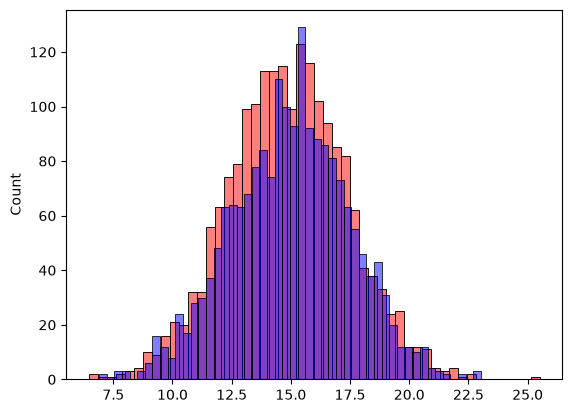

In [50]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)